<a href="https://colab.research.google.com/github/rxnu/LLM-Project/blob/main/2_reprensentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Representation

**Goal:**  
- Turn my cleaned text into numeric features  
- Train a simple baseline classifier (Logistic Regression)  
- Analyze performance and inspect which n-grams drive predictions  

In [ ]:
# Setup and Imports

from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

##  TF-IDF Vectorization

Convert each review into a TF-IDF weighted bag of unigrams + bigrams.


In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20_000,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_df["cleaned"])
X_test  = vectorizer.transform(test_df["cleaned"])

print("Feature matrix shapes:", X_train.shape, X_test.shape)


Feature matrix shapes: (25000, 20000) (25000, 20000)


## Train a Logistic Regression Baseline

A lightweight classifier lets me gauge how much signal my TF-IDF features capture.


In [ ]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_df["label"])

# Predictions
y_pred = clf.predict(X_test)

acc = accuracy_score(test_df["label"], y_pred)
f1  = f1_score(test_df["label"], y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test     F1 : {f1:.4f}")
print("\nClassification Report:\n",
      classification_report(test_df["label"], y_pred, target_names=["neg","pos"]))


Test Accuracy: 0.8830
Test     F1 : 0.8833

Classification Report:
               precision    recall  f1-score   support

         neg       0.89      0.88      0.88     12500
         pos       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## Confusion Matrix

Where does the baseline most often misclassify?


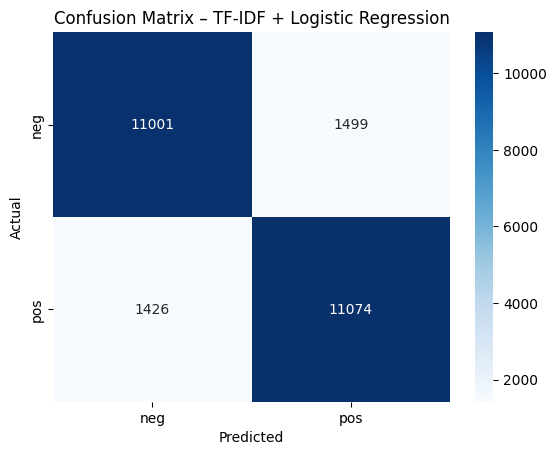

In [ ]:
cm = confusion_matrix(test_df["label"], y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","pos"], yticklabels=["neg","pos"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – TF-IDF + Logistic Regression")
plt.show()


## Top Predictive Features

Inspect the 10 highest‐weight features for each class.


In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

top_pos = feature_names[np.argsort(coefs)[-10:]]
top_neg = feature_names[np.argsort(coefs)[:10]]

print("Top positive indicators:", top_pos)
print("Top negative indicators:", top_neg)


Top positive indicators: ['love' 'loved' 'fun' 'favorite' 'amazing' 'perfect' 'wonderful' 'best'
 'excellent' 'great']
Top negative indicators: ['worst' 'bad' 'awful' 'boring' 'waste' 'poor' 'worse' 'terrible' 'dull'
 'poorly']


## Misclassification Examples

Read a few false positives & false negatives to understand errors.


In [ ]:
# identify indices
fp = np.where((test_df["label"]==0) & (y_pred==1))[0]
fn = np.where((test_df["label"]==1) & (y_pred==0))[0]

print("False positives (true=neg→pred=pos):")
for idx in fp[:3]:
    print("—", test_df["cleaned"].iloc[idx][:200], "\n")

print("\nFalse negatives (true=pos→pred=neg):")
for idx in fn[:3]:
    print("—", test_df["cleaned"].iloc[idx][:200], "\n")


False positives (true=neg→pred=pos):
— First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy thes 

— Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the 

— Low budget horror movie. If you don't raise your expectations too high, you'll probably enjoy this little flick. Beginning and end are pretty good, middle drags at times and seems to go nowhere for lo 


False negatives (true=pos→pred=neg):
— Its a very sensitive portrayal of life with unquenched or constrained desires. What does one do with desire in a culture and society with rigid norms? One husband finds outlet with the immigrant - sin 

— This was a bold movie to hit Indian cinemas when it was released. The first movie to perhaps openly dep

In [ ]:
# Saving to disk
ds.save_to_disk("/content/drive/MyDrive/imdb-tokenized-processed")


Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/50000 [00:00<?, ? examples/s]

## Reflection & Next Steps

- **Baseline Performance**  
  - TF-IDF + Logistic Regression achieved **88.29%** test accuracy and **F1 = 0.8832**.  
- **Error Analysis**  
  - The confusion matrix shows ~1,498 false positives (neg→pos) and ~1,429 false negatives (pos→neg), indicating a slight bias toward predicting positive.  
- **Top Predictive Features**  
  - **Positive indicators**: `['loved', 'love', 'fun', 'amazing', 'favorite', 'perfect', 'wonderful', 'best', 'excellent', 'great']`  
  - **Negative indicators**: `['worst', 'bad', 'awful', 'boring', 'waste', 'poor', 'worse', 'terrible', 'poorly', 'dull']`  
- **Misclassification Patterns**  
  - False positives often include mild praise (“if you don’t raise your expectations too high, you’ll probably enjoy this little flick”) even when the overall sentiment is negative or neutral.  
  - Often involve *irony, negation, or more complex structure*. For example the “good news… bad news” framing, or multi-sentence praise that isn’t straightforwardly positive.
- **Key Takeaways**  
  1. A simple TF-IDF bag-of-ngrams already captures strong sentiment signal (≈88%), but struggles with negation and nuance.  
  2. Many errors arise from context (“not good”, sarcastic phrasing) that necessitates a greater understanding than n-grams alone provide.  
  3. The relatively balanced confusion suggests both classes present similar challenges.  

**Next Step:**  
Fine-tune a transformer model (DistilBERT) to capture deeper context, handle negation and sarcasm, and close the gap on these misclassifications.
